In [1]:
import sys
print(sys.executable)

C:\Users\dpsvn\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (24322, 13)


,Latitude,Longitude,Beat,District,Ward,Community.Area,Hour,Month,Weekend,Night,Arrest,Domestic,Primary.Type
0,41.750690,-87.602742,624,6,8,44,0,2,1,1,0,1,BATTERY
1,41.943109,-87.649366,1924,19,44,6,0,2,1,1,0,0,THEFT
2,41.866969,-87.658439,1233,12,28,28,0,2,1,1,0,0,BATTERY
3,41.789196,-87.625157,232,2,20,40,0,2,1,1,0,0,OTHER OFFENSE
4,41.847406,-87.713654,1024,10,22,30,0,2,1,1,1,1,OTHER OFFENSE


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24322 entries, 0 to 24321
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Latitude        24322 non-null  float64
 1   Longitude       24322 non-null  float64
 2   Beat            24322 non-null  int64  
 3   District        24322 non-null  int64  
 4   Ward            24322 non-null  int64  
 5   Community.Area  24322 non-null  int64  
 6   Hour            24322 non-null  int64  
 7   Month           24322 non-null  int64  
 8   Weekend         24322 non-null  int64  
 9   Night           24322 non-null  int64  
 10  Arrest          24322 non-null  int64  
 11  Domestic        24322 non-null  int64  
 12  Primary.Type    24322 non-null  object 
dtypes: float64(2), int64(10), object(1)
memory usage: 2.4+ MB


,Latitude,Longitude,Beat,District,Ward,Community.Area,Hour,Month,Weekend,Night,Arrest,Domestic
count,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000,24322.000000
mean,41.844823,-87.666986,1129.337842,11.062659,22.608585,36.585190,12.434750,1.321314,0.288915,0.355892,0.159773,0.196365
std,0.085889,0.059020,707.782611,7.072790,13.889577,21.297413,6.678472,0.466991,0.453268,0.478792,0.366403,0.397256
min,41.645288,-87.927365,111.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,41.771744,-87.708036,523.000000,5.000000,9.000000,23.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,41.861335,-87.660101,1022.000000,10.000000,22.000000,32.000000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,41.906601,-87.625902,1723.000000,17.000000,34.000000,53.000000,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000
max,42.022535,-87.524652,2535.000000,25.000000,50.000000,77.000000,23.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Primary.Type"] = le.fit_transform(df["Primary.Type"])

df.head()

,Latitude,Longitude,Beat,District,Ward,Community.Area,Hour,Month,Weekend,Night,Arrest,Domestic,Primary.Type
0,41.750690,-87.602742,624,6,8,44,0,2,1,1,0,1,2
1,41.943109,-87.649366,1924,19,44,6,0,2,1,1,0,0,26
2,41.866969,-87.658439,1233,12,28,28,0,2,1,1,0,0,2
3,41.789196,-87.625157,232,2,20,40,0,2,1,1,0,0,19
4,41.847406,-87.713654,1024,10,22,30,0,2,1,1,1,1,19


In [6]:
features = [
    "Latitude",
    "Longitude",
    "Beat",
    "District",
    "Ward",
    "Community.Area",
    "Hour",
    "Month",
    "Weekend",
    "Night",
    "Arrest",
    "Domestic",
    "Primary.Type"
]

X = df[features]
X.head()

,Latitude,Longitude,Beat,District,Ward,Community.Area,Hour,Month,Weekend,Night,Arrest,Domestic,Primary.Type
0,41.750690,-87.602742,624,6,8,44,0,2,1,1,0,1,2
1,41.943109,-87.649366,1924,19,44,6,0,2,1,1,0,0,26
2,41.866969,-87.658439,1233,12,28,28,0,2,1,1,0,0,2
3,41.789196,-87.625157,232,2,20,40,0,2,1,1,0,0,19
4,41.847406,-87.713654,1024,10,22,30,0,2,1,1,1,1,19


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done")

Scaling done


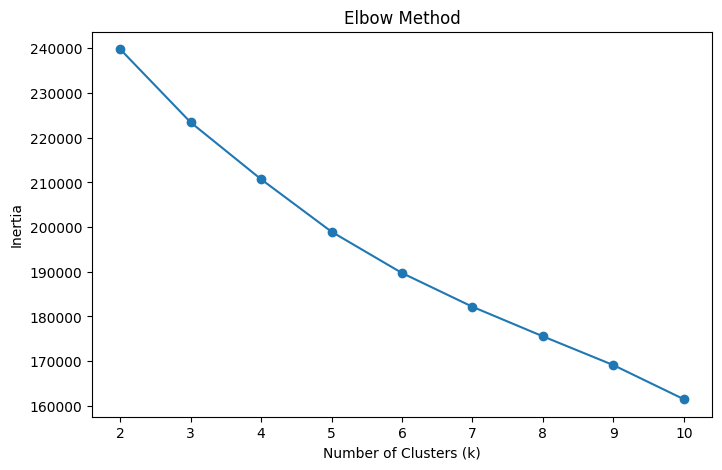

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.2193118062677696
k=3, Silhouette Score=0.17875838046403342
k=4, Silhouette Score=0.12592802628679314
k=5, Silhouette Score=0.13268641790188399
k=6, Silhouette Score=0.1391718029893881
k=7, Silhouette Score=0.12079358677007974


In [10]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

cluster
1    8879
2    6395
3    5513
0    3535
Name: count, dtype: int64

In [11]:
cluster_summary = df.groupby("cluster").agg({
    "Arrest": "mean",
    "Domestic": "mean",
    "Primary.Type": "mean",
    "Hour": "mean",
    "Latitude": "mean",
    "Longitude": "mean"
}).reset_index()

cluster_summary

,cluster,Arrest,Domestic,Primary.Type,Hour,Latitude,Longitude
0,0,0.163791,1.000000,6.678642,12.050919,41.784195,-87.644728
1,1,0.159928,0.000000,13.362203,12.395878,41.783451,-87.631280
2,2,0.132760,0.183425,12.382799,12.580453,41.946134,-87.708074
3,3,0.188282,0.012334,14.189189,12.574460,41.865024,-87.691104


In [12]:
risk_map = {
    3: "High Risk",
    2: "Moderate Risk",
    1: "Low Risk",
    0: "Very Low Risk"
}

df["risk_level"] = df["cluster"].map(risk_map)

df[["cluster", "risk_level"]].head()

,cluster,risk_level
0,0,Very Low Risk
1,2,Moderate Risk
2,3,High Risk
3,1,Low Risk
4,0,Very Low Risk


In [13]:
df.to_csv("../data/clustered/clustered_crime_data.csv", index=False)
print("Final clustered dataset saved.")

Final clustered dataset saved.
